<a href="https://colab.research.google.com/github/ldfha/RotemAI/blob/main/projects/pro14YOLO/yolo3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
# 이미지 감지 후 결과 출력
!pip install ultralytics opencv-python

In [27]:
import cv2
from ultralytics import YOLO
import numpy as np
import matplotlib.pyplot as plt
import os

model = YOLO('yolo11n.pt')

In [28]:
image_path = 'image1.jpg'
image = cv2.imread(image_path)
if image is None:
  print('이미지를 읽을 수 없어요')
  exit()

results = model(image)
# results = model(image, conf=0.8)
print(results)


0: 448x640 3 persons, 363.9ms
Speed: 6.0ms preprocess, 363.9ms inference, 4.4ms postprocess per image at shape (1, 3, 448, 640)
[ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: None
names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange'

감지된 사람 수는 3명


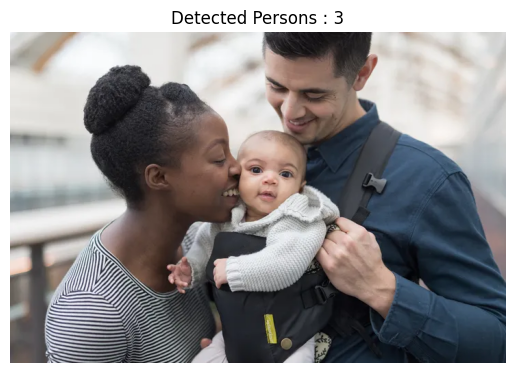

결과 이미지가 저장되었습니다 : yolo3output.jpg


In [29]:
# 원본 이미지 별도 기억
original = image.copy()

person_count = 0

for result in results:
  for box in result.boxes:
    x1,y1, x2,y2 = map(int, box.xyxy[0])  # 좌표 반환
    label = result.names[int(box.cls[0])] # 라벨명 반환
    confidence = box.conf[0].item()       # 신뢰도 반환

    if label.lower() == "person":
      person_count += 1

    # cv2.rectangle(image, (x1,y1), (x2,y2), (0,255,0), 2)
    # cv2.putText(image, f'{label}:{confidence:.2f}', (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

print(f'감지된 사람 수는 {person_count}명')

# 시각화
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title(f'Detected Persons : {person_count}')
plt.show()

# 바운딩 박스 결과를 이미지로 저장
output_path = 'yolo3output.jpg'
cv2.imwrite(output_path, image)
print(f'결과 이미지가 저장되었습니다 : {output_path}')

In [30]:
print('바운딩 박스 좌표 출력')
for result in results:
  for box in result.boxes:
    label = result.names[int(box.cls[0])]
    confidence = box.conf[0].item()
    x1, y1, x2, y2 = map(int, box.xyxy[0])
    print(f'라벨 : {label}, 신뢰도 : {confidence}, 좌표 :({x1}, {y1}), ({x2}, {y2})')

바운딩 박스 좌표 출력
라벨 : person, 신뢰도 : 0.8877398371696472, 좌표 :(49, 48), (331, 480)
라벨 : person, 신뢰도 : 0.8674443960189819, 좌표 :(369, 3), (723, 476)
라벨 : person, 신뢰도 : 0.6331340074539185, 좌표 :(231, 142), (483, 476)


In [31]:
# 신뢰도 높은 객체만 필터링 (예: 70% 이상)
for idx, result in enumerate(results):
  print(f'전체 라벨 중 이미지 {idx}번째 결과 :')
  found = False

  for box in result.boxes:
    label = result.names[int(box.cls[0])]
    confidence = box.conf[0].item()
    x1, y1, x2, y2 = map(int, box.xyxy[0])

    if confidence > 0.7:
      # print(f' - {label} {confidence:.2f}')
      found=True

  if not found:
    print('-  신뢰도 70% 이상인 객체가 없어요')

전체 라벨 중 이미지 0번째 결과 :


In [32]:
# 바운딩 박스 내부 객체 저장
for idx, result in enumerate(results):
  for j, box in enumerate(result.boxes):
    label = result.names[int(box.cls[0])]
    confidence = box.conf[0].item()
    x1, y1, x2, y2 = map(int, box.xyxy[0])

    # 이미지에서 ROI(Region Of Interest:관심영역) 추출
    cropped = image[y1:y2, x1:x2]   #  배열 슬라이싱(행방향, 열방향)

    # 저장 파일 만들기
    crop_path = f"crop_{j}_{label}_{confidence:.2f}.jpg"
    cv2.imwrite(crop_path, cropped)
    print(f' -> 객체 {label} 저장 성공 {crop_path}')

 -> 객체 person 저장 성공 crop_0_person_0.89.jpg
 -> 객체 person 저장 성공 crop_1_person_0.87.jpg
 -> 객체 person 저장 성공 crop_2_person_0.63.jpg


In [33]:
for idx, result in enumerate(results):
  for j, box in enumerate(result.boxes):
    label = result.names[int(box.cls[0])]
    confidence = box.conf[0].item()

    x1, y1, x2, y2 = map(int, box.xyxy[0])

    # 이미지에서 ROI(Region Of Interest:관심영역) 추출
    cropped = original[y1:y2, x1:x2]   #  배열 슬라이싱(행방향, 열방향)

    # 저장 파일 만들기
    crop_path = os.path.join('crops', f'crop_{idx}_{label}_{confidence:.2f}.jpg')
    cv2.imwrite(crop_path, cropped)
    print(f' -> 객체 {label} 저장(바운딩박스 X) 성공 {crop_path}')

 -> 객체 person 저장(바운딩박스 X) 성공 crops/crop_0_person_0.89.jpg
 -> 객체 person 저장(바운딩박스 X) 성공 crops/crop_0_person_0.87.jpg
 -> 객체 person 저장(바운딩박스 X) 성공 crops/crop_0_person_0.63.jpg


person => 1의 중심좌표:(190, 264), 신뢰도:0.89
person => 2의 중심좌표:(546, 239), 신뢰도:0.87
person => 3의 중심좌표:(357, 309), 신뢰도:0.63


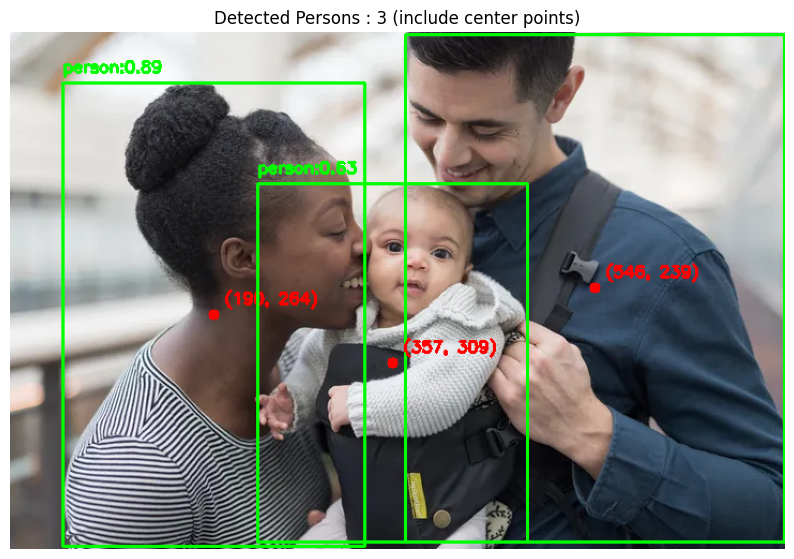

In [35]:
# 감지된 객체에 중심 좌표 출력 + 시각화
person_count = 0

for result in results:
  for box in result.boxes:
    label = result.names[int(box.cls[0])]
    confidence = box.conf[0].item()
    x1, y1, x2, y2 = map(int, box.xyxy[0])

    # 중심 좌표
    center_x = (x1 + x2) // 2
    center_y = (y1 + y2) // 2

    if label.lower() == "person":
      person_count += 1
      print(f'person => {person_count}의 중심좌표:({center_x}, {center_y}), 신뢰도:{confidence:.2f}')

      # 중심점을 원으로 그리기
      cv2.circle(image, (center_x, center_y), 5, (0, 0, 255), -1)

      coord_text = f'({center_x}, {center_y})'
      cv2.putText(image, coord_text, (center_x + 10, center_y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2)

      # 바운딩 박스 출력
      cv2.rectangle(image, (x1,y1), (x2,y2), (0,255,0), 2)
      cv2.putText(image, f'{label}:{confidence:.2f}', (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

plt.figure(figsize=(10, 10))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title(f'Detected Persons : {person_count} (include center points)')
plt.show()


0: 640x640 3 persons, 249.4ms
1: 640x640 2 persons, 1 dining table, 249.4ms
Speed: 5.0ms preprocess, 249.4ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)

이미지 0 (image1.jpg) 결과 :
 - person (0.89)
 - person (0.86)
 - person (0.67)

이미지 1 (image2.jpg) 결과 :
 - person (0.95)
 - person (0.90)
 - dining table (0.62)


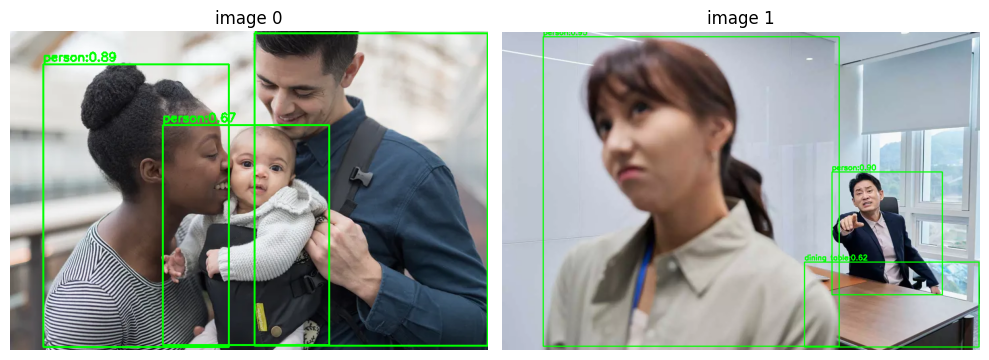

In [41]:
# 복수 이미지 처리
image_paths = ['image1.jpg', 'image2.jpg']
results = model(image_paths)

# 시각화
fig, axes = plt.subplots(1, len(image_paths), figsize=(10, 5))

for idx, (result, image_path) in enumerate(zip(results, image_paths)):
  print(f'\n이미지 {idx} ({image_path}) 결과 :')
  found = False

  # 원본 이미지 읽기
  image = cv2.imread(image_path)
  image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)

  for box in result.boxes:
    label = model.names[int(box.cls[0])]
    confidence = box.conf[0].item()

    if confidence >= 0.4:
      print(f' - {label} ({confidence:.2f})')
      found = True

      x1, y1, x2, y2 = map(int, box.xyxy[0])
      cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)
      cv2.putText(image, f'{label}:{confidence:.2f}', (x1, y1-5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

  if not found:
    print('-  신뢰도 40% 이상인 객체가 없어요')

  axes[idx].imshow(image)
  axes[idx].set_title(f'image {idx}')
  axes[idx].axis('off')

plt.tight_layout()
plt.show()